Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Dataset

Upload your CSV file in the notebook.

In [3]:
df = pd.read_csv('/content/fastag_transactions.csv')

df.head()

,txn_id,vehicle_id,plaza_id,txn_date,txn_time,amount,status,vehicle_type,bank_name,balance_before,balance_after
0,TXN000001,MH89AB1809,PLZ006,6/2/2024,23:21:05,180,SUCCESS,Truck,Kotak,288,108
1,TXN000002,MH61AB8605,PLZ003,1/12/2024,19:56:05,70,SUCCESS,Car,ICICI,1784,1714
2,TXN000003,MH15AB9995,PLZ001,6/8/2024,17:04:12,50,SUCCESS,Car,Axis,1933,1883
3,TXN000004,MH97AB9425,PLZ004,6/2/2024,0:34:40,100,SUCCESS,Bus,SBI,1283,1183
4,TXN000005,MH79AB7951,PLZ005,2/17/2024,20:39:21,140,SUCCESS,Bus,Kotak,1534,1394


Dataset Overview

In [4]:
print("Shape of dataset:", df.shape)

df.info()

df.describe()

Shape of dataset: (1000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   txn_id          1000 non-null   object
 1   vehicle_id      1000 non-null   object
 2   plaza_id        1000 non-null   object
 3   txn_date        1000 non-null   object
 4   txn_time        1000 non-null   object
 5   amount          1000 non-null   int64 
 6   status          1000 non-null   object
 7   vehicle_type    1000 non-null   object
 8   bank_name       1000 non-null   object
 9   balance_before  1000 non-null   int64 
 10  balance_after   1000 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 86.1+ KB


,amount,balance_before,balance_after
count,1000.000000,1000.000000,1000.000000
mean,118.420000,1098.611000,1003.421000
std,50.323315,517.976883,519.082233
min,50.000000,200.000000,3.000000
25%,70.000000,667.750000,569.250000
50%,120.000000,1097.500000,990.000000
75%,150.000000,1547.500000,1439.000000
max,200.000000,1998.000000,1995.000000


Check Missing Values

In [5]:
df.isnull().sum()

,0
txn_id,0
vehicle_id,0
plaza_id,0
txn_date,0
txn_time,0
amount,0
status,0
vehicle_type,0
bank_name,0
balance_before,0


Convert Date & Time Columns

In [6]:
df['txn_date'] = pd.to_datetime(df['txn_date'])
df['txn_time'] = pd.to_datetime(df['txn_time'], format='%H:%M:%S').dt.time

Total Transactions

In [7]:
total_transactions = df.shape[0] #gives number of rows in dataframe df
print("Total Transactions:", total_transactions)

Total Transactions: 1000



Transaction Status Distribution

status
SUCCESS     797
FAILED      153
REVERSED     50
Name: count, dtype: int64


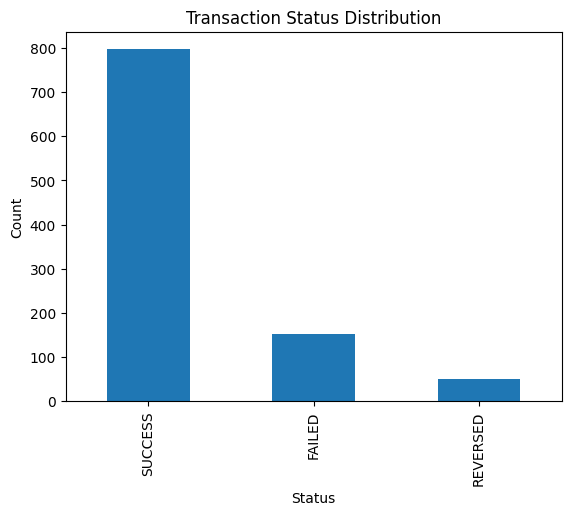

In [8]:
status_count = df['status'].value_counts()

print(status_count)

status_count.plot(kind='bar')
plt.title("Transaction Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

Total Revenue (SUCCESS only)

In [9]:
revenue = df[df['status']=='SUCCESS']['amount'].sum()

print("Total Revenue:", revenue)

Total Revenue: 95190


Revenue by toll plaza

plaza_id
PLZ004    17530
PLZ003    16420
PLZ005    16140
PLZ006    15890
PLZ001    15510
PLZ002    13700
Name: amount, dtype: int64


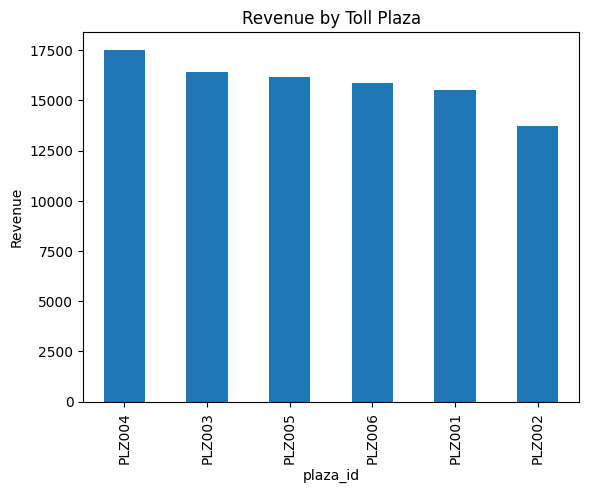

In [10]:
plaza_revenue = df[df['status']=='SUCCESS'].groupby('plaza_id')['amount'].sum().sort_values(ascending=False)

print(plaza_revenue)

plaza_revenue.plot(kind='bar')
plt.title("Revenue by Toll Plaza")
plt.ylabel("Revenue")
plt.show()

Vehicle Type Analysis

vehicle_type
Bus      29520
Car      16110
Truck    49560
Name: amount, dtype: int64


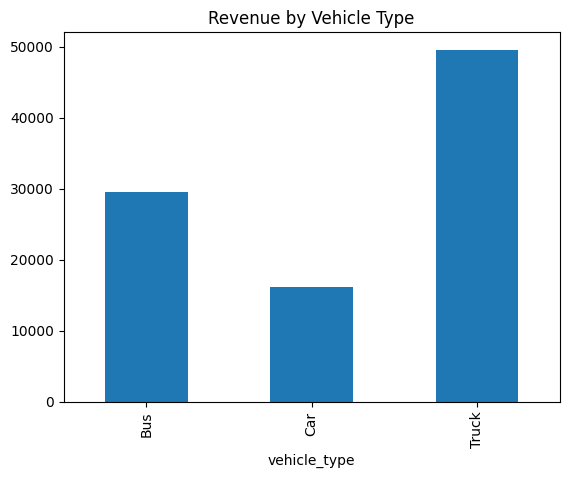

In [11]:
vehicle_revenue = df[df['status']=='SUCCESS'].groupby('vehicle_type')['amount'].sum()

print(vehicle_revenue)

vehicle_revenue.plot(kind='bar')
plt.title("Revenue by Vehicle Type")
plt.show()

Bank-wise Transactions

bank_name
Axis     233
SBI      203
Kotak    197
ICICI    184
HDFC     183
Name: count, dtype: int64


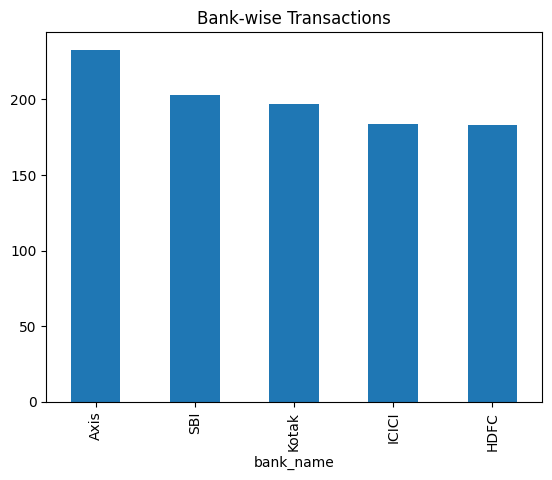

In [12]:
bank_transactions = df['bank_name'].value_counts()

print(bank_transactions)

bank_transactions.plot(kind='bar')
plt.title("Bank-wise Transactions")
plt.show()

Peak Traffic Hours

In [13]:
df['txn_hour'] = pd.to_datetime(df['txn_time'], format='%H:%M:%S').dt.hour #create hour column

txn_hour
0     29
1     43
2     44
3     47
4     31
5     40
6     48
7     38
8     39
9     35
10    34
11    44
12    46
13    45
14    43
15    41
16    40
17    32
18    40
19    54
20    36
21    57
22    38
23    56
dtype: int64


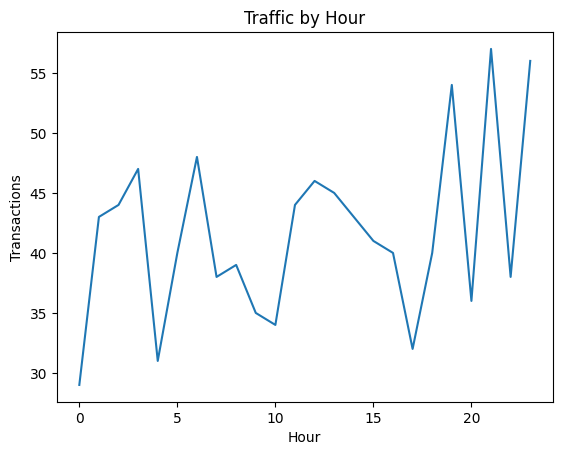

In [14]:
traffic_hour = df.groupby('txn_hour').size() #analyze traffic

print(traffic_hour)

traffic_hour.plot()
plt.title("Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

Daily Revenue Trend

txn_date
2024-01-01    1210
2024-01-02     620
2024-01-03     450
2024-01-04     620
2024-01-05     210
              ... 
2024-06-25    1190
2024-06-26     660
2024-06-27     280
2024-06-28     900
2024-06-29     410
Name: amount, Length: 181, dtype: int64


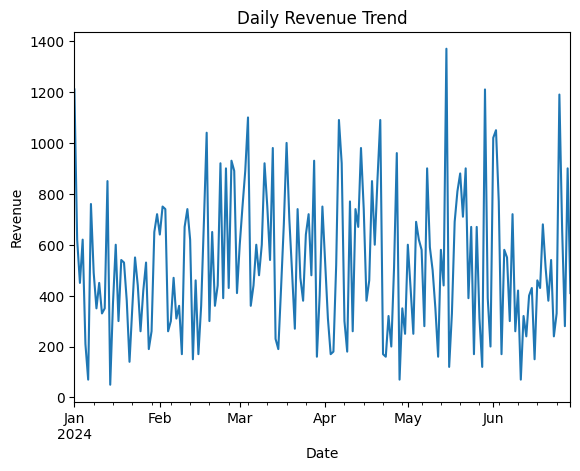

In [15]:
daily_revenue = df[df['status']=='SUCCESS'].groupby('txn_date')['amount'].sum()

print(daily_revenue)

daily_revenue.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

Failed Transactions Analysis

In [16]:
failed_txn = df[df['status']=='FAILED']

failed_by_plaza = failed_txn['plaza_id'].value_counts()

print(failed_by_plaza)

plaza_id
PLZ002    30
PLZ003    28
PLZ006    27
PLZ005    27
PLZ001    22
PLZ004    19
Name: count, dtype: int64


Wallet Balance Validation

In [17]:
balance_issue = df[df['balance_after'] != df['balance_before'] - df['amount']]

print(balance_issue.head())

       txn_id  vehicle_id plaza_id   txn_date  txn_time  amount    status  \
11  TXN000012  MH86AB6753   PLZ002 2024-06-21  17:14:53     120    FAILED   
14  TXN000015  MH29AB6062   PLZ001 2024-05-24  16:16:50     100  REVERSED   
21  TXN000022  MH79AB3200   PLZ003 2024-02-20  21:34:01     140    FAILED   
27  TXN000028  MH95AB5314   PLZ004 2024-02-27  22:35:21      50    FAILED   
29  TXN000030  MH44AB9475   PLZ006 2024-03-21  06:47:24     100  REVERSED   

   vehicle_type bank_name  balance_before  balance_after  txn_hour  
11          Bus     ICICI             891            891        17  
14          Bus       SBI             916            916        16  
21          Bus       SBI             295            295        21  
27          Car     Kotak             832            832        22  
29          Bus      Axis             765            765         6  


Top Vehicles by Transactions

vehicle_id
MH67AB1254    1
MH89AB1809    1
MH61AB8605    1
MH15AB9995    1
MH97AB9425    1
MH79AB7951    1
MH56AB4287    1
MH79AB8672    1
MH15AB6269    1
MH45AB3724    1
Name: count, dtype: int64


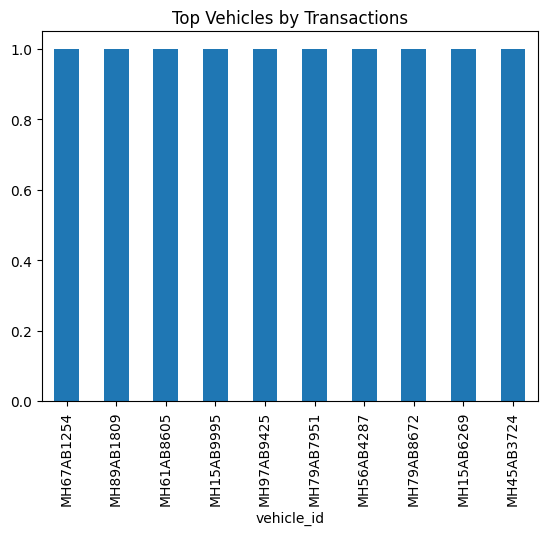

In [18]:
top_vehicle = df['vehicle_id'].value_counts().head(10)

print(top_vehicle)

top_vehicle.plot(kind='bar')
plt.title("Top Vehicles by Transactions")
plt.show()

Anomaly Detection (High Amount Transactions)

In [19]:
threshold = df['amount'].mean() + 2 * df['amount'].std()

high_value = df[df['amount'] > threshold]

print(high_value.head())

Empty DataFrame
Columns: [txn_id, vehicle_id, plaza_id, txn_date, txn_time, amount, status, vehicle_type, bank_name, balance_before, balance_after, txn_hour]
Index: []


Key Insights Print

In [20]:
print("Key Insights:")
print("1. Total Revenue:", revenue)
print("2. Top Plaza:", plaza_revenue.idxmax())
print("3. Most Used Bank:", bank_transactions.idxmax())
print("4. Peak Traffic Hour:", traffic_hour.idxmax())

Key Insights:
1. Total Revenue: 95190
2. Top Plaza: PLZ004
3. Most Used Bank: Axis
4. Peak Traffic Hour: 21
